In this Notebook we explore the propagation of the mean density in of LLNAs on Watts-Strogatz networks for various rewiring probabilities.

We will do the following:
- Create W-S graph with $N=100$ nodes for $p \in \{0, 0.2, 1\}$. For $p=0$ we have the familiar case of a CA, and for $p=1$ we have the well-explored case of a Erdös-Renyi random network.
- Choose a particularly interesting rule, preferably one that makes sense as a CA (on a ring graph)
- Take various initial configurations with a particular density, and evolve the system over $T=100$ time steps
- Plot the mean and the variance of the evolution of the densities for a variety of $p$ values
- Plot the final value and variance for all rules of a particular resolution and compare this to the value that is predicted from the mean-field approach

In [3]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire

%load_ext autoreload
%autoreload 2

# Create a number of networks

Some notes:
- We need to make sure that the network is connected (no separate graphs)
- If we want to turn a ring graph into a random network, the condition for connectedness turns it into a very long waiting time
- If we start with a ring graph (like ECAs), the random networks turn out quite ugly (very unconnected)
- If I want to start off with a Game of Life network, the plotting does not work (makes the whole thing crash). And just making the network already takes a long time! Don't really understand why. I think the `dim=2` kwarg is just broken. There are probably ways around this, but let's just start with a different scenario for now.

Some remarkable rules:
- $R_5 B_7 S_4$ (oscillation modulation)
- OT-5 = $R_5 B_{20} S_{14}$: birth on 2 or 4, survive on 1-3: produces localised structures, travelling waves etc.
- OT-7 = $R_5 B_{24} S_{24}$: majority voting (zogezegd, maar niet heel boeiend)

Some clean, easy-to-use rules

- R5 B11 S27
- R5 B15 S9
- R5 B20 S19
- R5 B10 S31: widens out
- R5 B6 S2: large initial populations will go extinct
- R5 B12 S11: convergence is broken for low initial densities
- R5 B28 S5: convergence is broken again (only intermediate initial densities survive). similar for R5 B11 S24 and for R5 B16 S27
- R5 B9 S7: different kinds of oscillatory behaviour
- R5 B10 S29: widening of the convergence values
- R5 B23 S12: effect on oscillations (no oscillation in small-world)
- R5 B1 S25: quite interesting! convergence is changed quite clearly. Similarly for R5 B17 S25. Similarly for R5 B20 S30

Some notable life-like rules listed on Wikipedia:

<img src='pictures/notable-life-like-rules.PNG' width="700">

These translate to

| Original notation | Our notation |
|-------------------|--------------|
| B1357/S1357   | $R_9 B_{170} S_{170}$ |
| B2/S          | $R_9 B_{4} S_{0}$     |
| B25/S4        | $R_9 B_{36} S_{16}$   |
| B3/S012345678 | $R_9 B_{8} S_{511}$   |
| B3/S23        | $R_9 B_{8} S_{12}$    |
| B34/S34       | $R_9 B_{24} S_{24}$   |
| B35678/S5678  | $R_9 B_{488} S_{480}$ |
| B36/S125      | $R_9 B_{72} S_{38}$   |
| B36/S23       | $R_9 B_{72} S_{12}$   |
| B3678/S34678  | $R_9 B_{456} S_{472}$ |
| B368/S245     | $R_9 B_{328} S_{52}$  |
| B4678/S35678  | $R_9 B_{464} S_{488}$ |

In [43]:
VISUALISE=False

# Parameters
L = 10                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
num_nodes = L**2
rewiring_prob = 0.2     # Rewiring probability

# Create toroidal lattice and rewire
lattice_graph = create_2d_torus_lattice(L, degree=8)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

# save graphs and edges in list
graphs = [lattice_graph, small_world_graph, random_graph]
graph_names = ["Lattice", f"Small World ($p={rewiring_prob}$)", "Random"]
edges = [lattice_edges, small_world_edges, random_edges]

if VISUALISE:
    # Optional: Visualize
    fig, axs = plt.subplots(1,3,figsize=(15,5))
    layout = lattice_graph.layout("grid")  # Grid layout
    vertex_size  = 5
    edge_width = 0.5
    fontsize = 22

    for ax, graph, name in zip(axs, graphs, graph_names):
        ig.plot(graph, layout=layout, vertex_size=vertex_size, edge_width=edge_width, target=ax)
        ax.set_title(name, fontsize=fontsize)

In [8]:
from src.rules import return_life_like_dict
life_like_dict = return_life_like_dict()
life_like_dict

{'replicator': (170, 170),
 'seeds': (4, 0),
 'no_name': (36, 16),
 'life_without_death': (8, 511),
 'life': (8, 12),
 '34_life': (24, 24),
 'diamoeba': (488, 480),
 '2x2': (72, 38),
 'highlife': (72, 12),
 'day&night': (456, 472),
 'morley': (328, 52),
 'anneal': (464, 488)}

In [7]:
# make LLCAs on graphs
resolution = 9
life_like_name = "anneal"
beta, sigma = life_like_dict[life_like_name]
# beta = 72
# sigma = 12
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
# model = LLNA(resolution, iso=True)
T = 4*L

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

num_config = 10
init_dens = 0.5

init_configs = np.array([init_config_with_dens(L*L, init_dens) for _ in range(num_config)])
# init_defects = np.array([init_config_with_dens(L*L, 1/L/L) for _ in range(num_config)])
# init_configs_defect = (init_configs + init_defects) % 2
# run simulation over a number of time steps
configs = model.forward(lattice_edges, tc.tensor(init_configs), T=T).numpy().astype(int)
# configs_defect = model.forward(lattice_edges, tc.tensor(init_configs_defect), T=T).numpy().astype(int)
# defects = (configs + configs_defect) % 2

# put back in L x L shape 
configs = configs.reshape((num_config, T+1, L, L))
# defects = defects.reshape((num_config, T+1, L, L))

In [8]:
# animations
import matplotlib.animation as animation
from IPython.display import HTML

def make_animation_object(grids):
    # Set up figure
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(grids[0])
    # Update function for animation
    def update(frame):
        im.set_array(grids[frame])
        # ax.set_title(f"{model.__str__(latex=True)} on a lattice network,\nTime step {frame}", fontsize=16)
        ax.set_xticks([]); ax.set_yticks([])
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=T+1, interval=100)
    plt.close()
    return ani

In [9]:
SAVEGIF = False
savename = f"animation_hamming_weight_all_res{resolution}_LLNAs.gif"

example_idx = np.random.randint(num_config)
ani = make_animation_object(configs[example_idx])
# ani = make_animation_object(defects[example_idx])

if SAVEGIF:
    # Save animations as GIFs
    loc = '../figures/gifs/'
    ani.save(loc+savename, writer='pillow', fps=16)  # Using Pillow

# show inline
HTML(ani.to_jshtml())

In [9]:
from src.rules import return_life_like_dict
life_like_dict = return_life_like_dict()
# {'replicator': (170, 170),        # boring, just goes to full randomness with mean state average
#  'seeds': (4, 0),                 # also clearly different behaviour between topologies! visually less interesting, though
#  'no_name': (36, 16),             # converges to 0.25, but dies out for rull randomness. Visually quite boring.
#  'life_without_death': (8, 511),  # clear convergence points. No real difference between topologies
#  'life': (8, 12),                 # clear topological influence, but visually not the most interesting
#  '34_life': (24, 24),             # convergence to ~0.45. Not super interesting visually
#  'diamoeba': (488, 480),          # pretty clear topological influence. goes to a monochrome finale
#  '2x2': (72, 38),                 # boring
#  'highlife': (72, 12),            # PODIUMPLAATS - topological influence, and looks quite nice :)
#  'day&night': (456, 472),         # divergent, but stabilised by randomn network
#  'morley': (328, 52),             # WINNAAR nice and clean, clear difference between different topologies
#  'anneal': (464, 488)}            # divergent, and (opposite from day&night) divergence is reinforced by network randomness!
life_like_dict

{'replicator': (170, 170),
 'seeds': (4, 0),
 'no_name': (36, 16),
 'life_without_death': (8, 511),
 'life': (8, 12),
 '34_life': (24, 24),
 'diamoeba': (488, 480),
 '2x2': (72, 38),
 'highlife': (72, 12),
 'day&night': (456, 472),
 'morley': (328, 52),
 'anneal': (464, 488)}

100%|██████████| 3/3 [00:05<00:00,  1.77s/it]


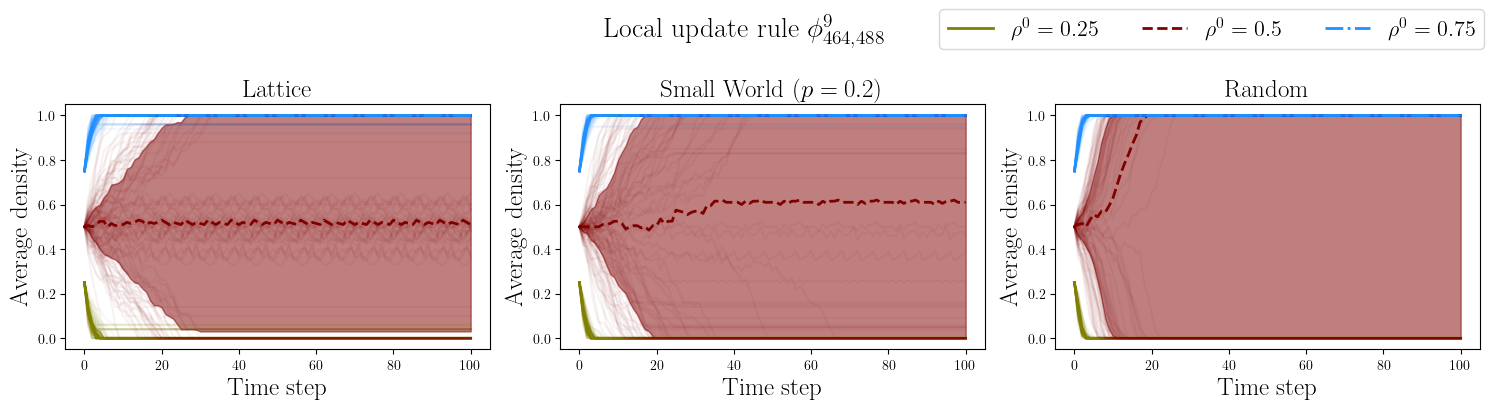

In [44]:
# make simple totalistic CA with radius 2
resolution = 9
# beta = 8
# sigma = 12
beta, sigma = life_like_dict["anneal"]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
# model = LLNA(resolution, iso=True)
T = 100

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

num_config = 100
init_dens_list = [0.25, 0.5, 0.75]
init_dens_colors = ['olive', 'maroon', 'dodgerblue']
ls_list = ['-', '--', '-.']

dens_list_per_graph = []

fig, axs = plt.subplots(1, len(graphs), figsize=(5*len(graphs), 4))
fontsize=18
alpha_factor = 0.05

for edge, graph_name, ax in tqdm(zip(edges, graph_names, axs), total=len(edges)):
    dens_list_per_init_dens = []
    for init_dens, color, ls in zip(init_dens_list, init_dens_colors, ls_list):
        init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
        # run simulation over a number of time steps
        configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        # calculate the means over all nodes
        means_over_nodes = np.mean(configs, axis=2).T
        dens_list_per_init_dens.append(means_over_nodes)
        # calcule the quartiles for each time step
        Q1_of_means = np.quantile(means_over_nodes, 0.25, axis=1)
        Q2_of_means = np.quantile(means_over_nodes, 0.50, axis=1)
        Q3_of_means = np.quantile(means_over_nodes, 0.75, axis=1)
        # plot
        ax.plot(means_over_nodes, alpha=alpha_factor*100/num_config, color=color)
        ax.plot(Q2_of_means, lw=2, color=color, ls=ls, label=f"$\\rho^0 = {init_dens}$")
        ax.fill_between(range(T+1), Q1_of_means, Q3_of_means, lw=1, color=color, alpha=0.5)
    # save information to list
    dens_list_per_graph.append(dens_list_per_init_dens)
    # plot information
    ax.set_title(f"{graph_name}", fontsize=fontsize)
    ax.set_xlabel("Time step", fontsize=fontsize)
    ax.set_ylabel("Average density", fontsize=fontsize)
    ax.set_ylim([-0.05, 1.05])
dens_array_per_graph = np.array(dens_list_per_graph)

# axs[-1].legend(fontsize=fontsize-4, loc='lower right', ncol=3)

# Add a single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=len(init_dens_list), fontsize=fontsize-2, bbox_to_anchor=(1, 1.04) )

fig.suptitle(f"Local update rule {model.__str__(latex=True)}", fontsize=fontsize+2, y=1)
fig.tight_layout()

### Calculate convergence values and standard deviations

From an ensemble of time series, we want to do the following
1. Cut off the final 10 time steps of the simulation
2. Find mean and standard deviation of each time series
3. Find mean of all means and standard deviation of all means
4. Plot these final values against particular parameters, such as rewiring probability and initial state density

We will calculate the mean and variation of a single time series for a last so-many time steps
$$
\mu_i = \frac{1}{\Delta t} \sum_{t = t_0}^{T} x_i(t), \qquad \text{and } \qquad \sigma_i^2 = \frac{1}{\Delta t} \sum_{t = t_0}^{T} \left( x_i(t) - \mu_i \right)^2
$$
where $t_0$ is some value at the end: $t_0 = T - \Delta t + 1$.

The average and variance over the ensemble is
$$
\mu_{\text{ensemble}} = \frac{1}{N} \sum_{i = 1}^{N} \mu_i, \qquad \text{and } \qquad \sigma_{\text{ensemble}}^2 = \frac{1}{N} \sum_{i = 1}^{N} \left( \mu_i - \mu_{\text{ensemble}} \right)^2
$$

Therefore the total mean and variance become
$$
\mu(\rho^t) = \frac{1}{\Delta t N} \sum_{i=1}^N \sum_{t=t_0}^T x_i(t), \qquad \text{and } \qquad \sigma^2(\rho^t) = \frac{1}{N} \sum_{i = 1}^{N} \left[\sigma_i^2 + \left( \mu_i - \mu_{\text{ensemble}} \right)^2\right]
$$

In [150]:
def median_and_uncertainties(arrays, delta_t, lower_percentile=0.25, upper_percentile=0.75):
    if arrays.ndim != 2:
        raise ValueError(f"The input array has {arrays.ndim} dimensions instead of 2.")
    if (lower_percentile > 0.5) or (upper_percentile < 0.5):
        raise ValueError("The median is not within the percentiles.")
    final_timesteps = arrays[-delta_t:]
    median = np.median(final_timesteps)
    lw_perc = np.quantile(final_timesteps, lower_percentile)
    up_perc = np.quantile(final_timesteps, upper_percentile)
    neg_uncertainty = median - lw_perc
    pos_uncertainty = up_perc - median
    return median, neg_uncertainty, pos_uncertainty

In [143]:
from src.rules import get_nonequiv_rules
resolution = 3
nonequiv_rules_r3 = get_nonequiv_rules(resolution)

In [149]:
# model = LLNA(resolution, iso=True)
T = 100

resolution = 9
beta, sigma = life_like_dict["morley"]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

# Parameters
L = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
num_nodes = L**2
rewiring_prob = 0.2     # Rewiring probability

# Create toroidal lattice and rewire
lattice_graph = create_2d_torus_lattice(L, degree=8)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

# find edges
small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

# find edges
random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

edges = [lattice_edges, small_world_edges, random_edges]

num_config = 100
init_dens_res = 51
init_dens_array = np.linspace(0,1,init_dens_res)
delta_t = 10

dens_list_per_init_dens_per_graph = []
median_list_per_graph = []
neg_uncertainty_list_per_graph = []
pos_uncertainty_list_per_graph = []
for i, edge in enumerate(edges):
    print(f"Working on graph {i+1}.")
    dens_list_per_init_dens = []
    median_list = []
    neg_uncertainty_list = []
    pos_uncertainty_list = []
    for init_dens in tqdm(init_dens_array, total=len(init_dens_array)):
        init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
        # run simulation over a number of time steps
        configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        # calculate the means over all nodes
        means_over_nodes = np.mean(configs, axis=2).T
        dens_list_per_init_dens.append(means_over_nodes)
        # calcule the median and quantiles
        final_timesteps = means_over_nodes[:,-delta_t:]
        median, neg_uncertainty, pos_uncertainty = median_and_uncertainties(final_timesteps, delta_t)
        median_list.append(median)
        neg_uncertainty_list.append(neg_uncertainty)
        pos_uncertainty_list.append(pos_uncertainty)
    dens_list_per_init_dens_per_graph.append(dens_list_per_init_dens)
    median_list_per_graph.append(median_list)
    neg_uncertainty_list_per_graph.append(neg_uncertainty_list)
    pos_uncertainty_list_per_graph.append(pos_uncertainty_list)
dens_list_per_init_dens_per_graph = np.array(dens_list_per_init_dens_per_graph)
median_list_per_graph = np.array(median_list_per_graph)
neg_uncertainty_list_per_graph = np.array(neg_uncertainty_list_per_graph)
pos_uncertainty_list_per_graph = np.array(pos_uncertainty_list_per_graph)

Working on graph 1.


100%|██████████| 51/51 [01:16<00:00,  1.50s/it]


Working on graph 2.


100%|██████████| 51/51 [01:18<00:00,  1.53s/it]


Working on graph 3.


100%|██████████| 51/51 [01:17<00:00,  1.52s/it]


In [184]:
# Parameters
L = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
num_nodes = L**2
rewiring_res = 51
rewiring_prob_array = np.logspace(-3,0,rewiring_res)

# Create toroidal lattice and rewire
lattice_graph = create_2d_torus_lattice(L, degree=8)
graphs = [watts_strogatz_rewire(lattice_graph, rewiring_prob) for rewiring_prob in rewiring_prob_array]
edges = []
for graph in graphs:
    # find edges
    graph.to_directed()
    edge = tc.tensor(graph.get_edgelist()).T
    edges.append(edge)
    graph.to_undirected()

num_config = 1000
delta_t = 10

init_dens_list = [0.25, 0.5, 0.75]
dens_list_per_graph_per_init_dens = []
median_list_per_init_dens = []
neg_uncertainty_list_per_init_dens = []
pos_uncertainty_list_per_init_dens = []
for i, init_dens in enumerate(init_dens_list):
    print(f"Working on init_dens {i+1}.")
    dens_list_per_graph = []
    median_list = []
    neg_uncertainty_list = []
    pos_uncertainty_list = []
    for edge in tqdm(edges, total=len(init_dens_array)):
        init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
        # run simulation over a number of time steps
        configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        # calculate the means over all nodes
        means_over_nodes = np.mean(configs, axis=2).T
        dens_list_per_graph.append(means_over_nodes)
        # calcule the median and quantiles
        final_timesteps = means_over_nodes[:,-delta_t:]
        median, neg_uncertainty, pos_uncertainty = median_and_uncertainties(final_timesteps, delta_t)
        median_list.append(median)
        neg_uncertainty_list.append(neg_uncertainty)
        pos_uncertainty_list.append(pos_uncertainty)
    dens_list_per_graph_per_init_dens.append(dens_list_per_graph)
    median_list_per_init_dens.append(median_list)
    neg_uncertainty_list_per_init_dens.append(neg_uncertainty_list)
    pos_uncertainty_list_per_init_dens.append(pos_uncertainty_list)
dens_list_per_graph_per_init_dens = np.array(dens_list_per_graph_per_init_dens)
median_list_per_init_dens = np.array(median_list_per_init_dens)
neg_uncertainty_list_per_init_dens = np.array(neg_uncertainty_list_per_init_dens)
pos_uncertainty_list_per_init_dens = np.array(pos_uncertainty_list_per_graph)

Working on init_dens 1.


100%|██████████| 51/51 [09:43<00:00, 11.45s/it]


Working on init_dens 2.


100%|██████████| 51/51 [10:43<00:00, 12.61s/it]


Working on init_dens 3.


100%|██████████| 51/51 [10:14<00:00, 12.05s/it]


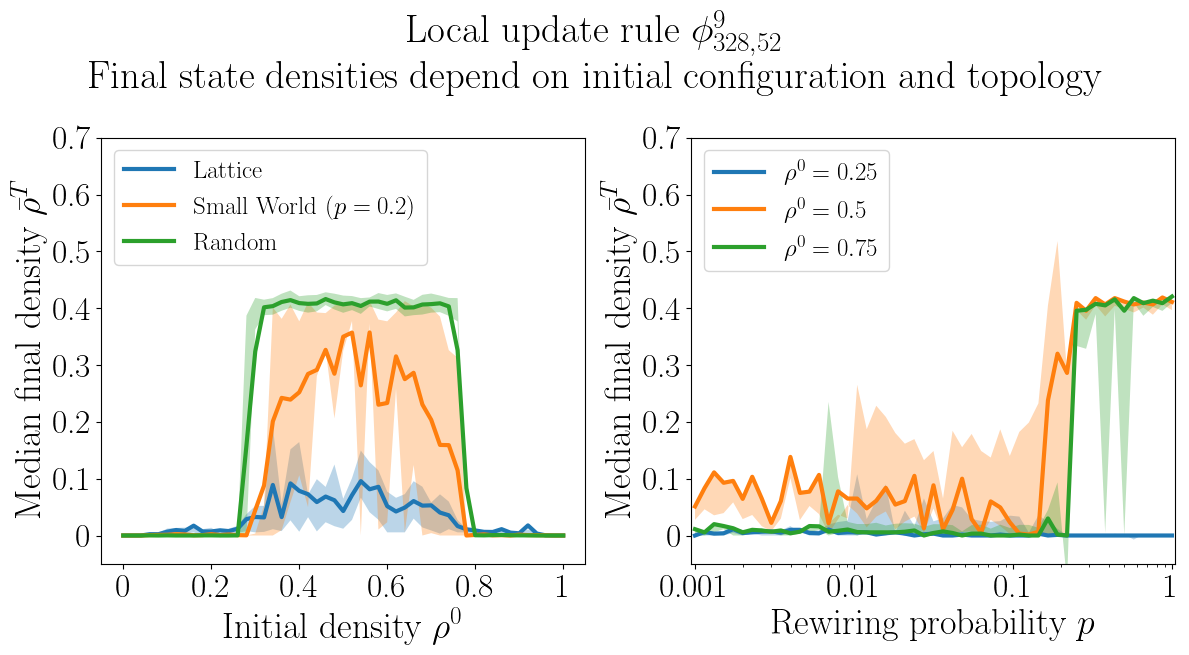

In [194]:
fig, axs = plt.subplots(1,2,figsize=(12,6.5))
fontsize=26

for median_list, neg_uncertainty_list, pos_uncertainty_list, graph_name in zip(median_list_per_graph,
                                                                      neg_uncertainty_list_per_graph,
                                                                      pos_uncertainty_list_per_graph,
                                                                      graph_names):
    axs[0].plot(init_dens_array, median_list, lw=3, label=graph_name)
    axs[0].fill_between(init_dens_array, median_list-neg_uncertainty_list, median_list+pos_uncertainty_list, alpha=0.3)

for median_list, neg_uncertainty_list, pos_uncertainty_list, init_dens in zip(median_list_per_init_dens,
                                                                      neg_uncertainty_list_per_init_dens,
                                                                      pos_uncertainty_list_per_init_dens,
                                                                      init_dens_list):
    axs[1].plot(rewiring_prob_array, median_list, lw=3, label=f"$\\rho^0 = {init_dens}$")
    axs[1].fill_between(rewiring_prob_array, median_list-neg_uncertainty_list, median_list+pos_uncertainty_list, alpha=0.3)
    axs[1].set_xscale('log')

axs[0].set_ylabel("Median final density $\\bar{\\rho}^T$", fontsize=fontsize)
axs[0].set_xlabel("Initial density $\\rho^0$", fontsize=fontsize)
axs[0].legend(fontsize=fontsize-8, loc='upper left')

axs[0].set_ylim([-0.05,0.7])
axs[0].set_xlim([-0.05, 1.05])

# left plot
xticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
yticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks, fontsize=fontsize-2)
axs[0].set_yticks(yticks)
axs[0].set_yticklabels(yticks, fontsize=fontsize-2)

# right plot
axs[1].legend(fontsize=fontsize-8, loc='upper left')
axs[1].set_ylabel("Median final density $\\bar{\\rho}^T$", fontsize=fontsize)
axs[1].set_xlabel(f"Rewiring probability $p$", fontsize=fontsize)
axs[1].set_ylim([-0.05,0.7])
axs[1].set_xlim([0.001*0.95, 1*1.05])
xticks = [0.001, 0.01, 0.1, 1]
yticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
# axs[1].set_yscale('log')
axs[1].set_xticks(xticks)
axs[1].set_xticklabels(xticks, fontsize=fontsize-2)
axs[1].set_yticks(yticks)
axs[1].set_yticklabels(yticks, fontsize=fontsize-2)

fig.suptitle(f"Local update rule {model.__str__(latex=True)}\nFinal state densities depend on initial configuration and topology", fontsize=fontsize+2, y=1)
fig.tight_layout()

savename = "final_state_densities_vs_init_conf_and_topology.pdf"
plt.savefig(f"{savename}", bbox_inches='tight')

In [141]:
len(median_list)

31

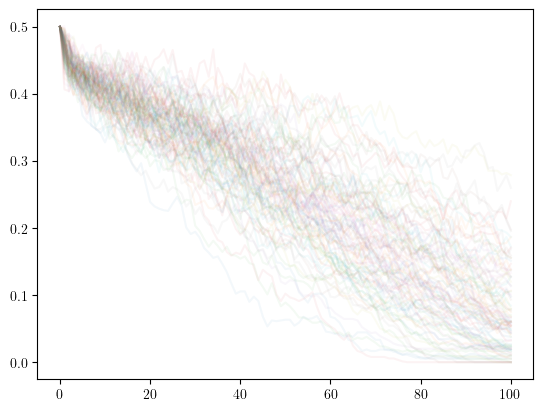

In [134]:
_ = plt.plot(np.array(dens_list_per_init_dens)[15], alpha=0.05)

# How does a single seed spread out?

counterpart of defect spread (but arguably less relevant)

Now, instead of taking the average over all nodes, let us consider the following:
1. Start with a single seed
2. Plant this seed in each of the nodes
3. Look at how the seeds spreads through the network by considering the diameter of the affected subgraph (the width of the cone in the spacetime diagram)

100%|██████████| 3/3 [00:18<00:00,  6.17s/it]


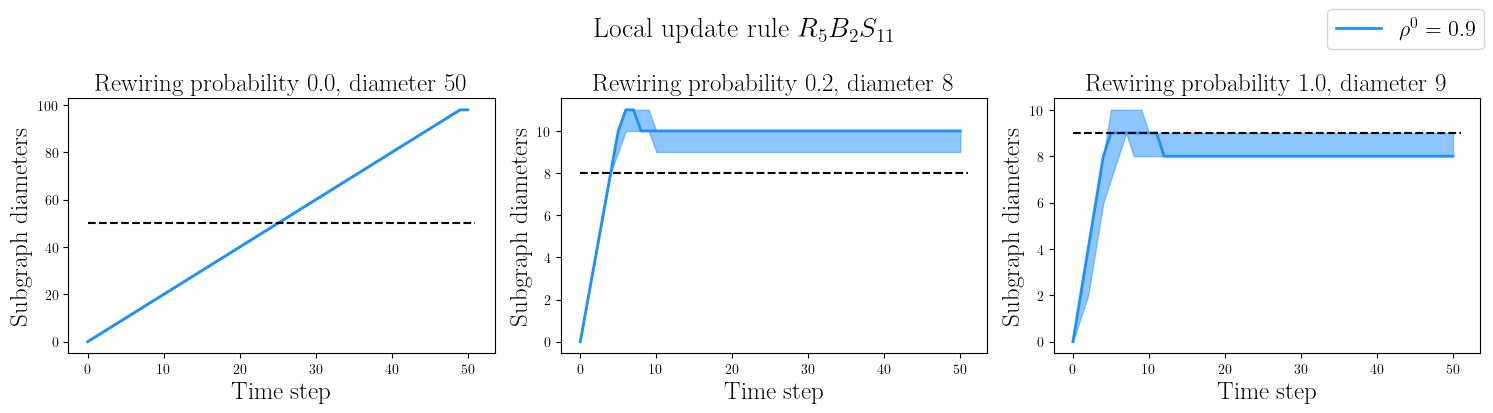

In [560]:
# make simple totalistic CA with radius 2
resolution = 5
beta = 2
sigma = 11
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
# model = LLNA(resolution, iso=True)
T = 50

# single-seed initial configuration for each node
init_configs = np.eye(num_nodes)

fig, axs = plt.subplots(1, prob_resolution, figsize=(5*prob_resolution, 4))
fontsize=18
alpha_factor = 0.03

for ws_edge, ws_graph, rewiring_prob, ax in tqdm(zip(ws_edges, ws_graphs, rewiring_probs, axs), total=prob_resolution):
    # run simulation over a number of time steps
    configs = model.forward(ws_edge, tc.tensor(init_configs), T=T).numpy().astype(int)
    # find nodes with an activation history with a 1
    configs_cum = np.cumsum(configs, axis=1)
    configs_cum = np.clip(configs_cum, 0, 1)
    # define subgraph for each of the defects at all intermediate times
    Q1_diameters = []
    Q2_diameters = []
    Q3_diameters = []
    # NOTE: this is probably not coded very well (loops)
    for time in range(T+1):
        diameters = []
        for seed_idx in range(num_nodes):
            config_cum = configs_cum[seed_idx, time]
            nodes_with_life_history, = np.where(config_cum)
            subG = ws_graph.subgraph(nodes_with_life_history)
            diameter = subG.diameter()
            diameters += [diameter]
        diameters = np.array(diameters)
        Q1_of_diameters_t = np.quantile(diameters, 0.25)
        Q2_of_diameters_t = np.quantile(diameters, 0.50)
        Q3_of_diameters_t = np.quantile(diameters, 0.75)
        Q1_diameters.append(Q1_of_diameters_t)
        Q2_diameters.append(Q2_of_diameters_t)
        Q3_diameters.append(Q3_of_diameters_t)
    # plot
    graph_diam = ws_graph.diameter()
    ax.plot([0,T+1], [graph_diam,graph_diam], 'k--', zorder=10)
    ax.plot(Q2_diameters, lw=2, color=color, ls='-', label=f"$\\rho^0 = {init_dens}$")
    ax.fill_between(range(T+1), Q1_diameters, Q3_diameters, lw=1, color=color, alpha=0.5)
    ax.set_title(f"Rewiring probability {round(rewiring_prob,2)}, diameter {graph_diam}", fontsize=fontsize)
    ax.set_xlabel("Time step", fontsize=fontsize)
    ax.set_ylabel("Subgraph diameters", fontsize=fontsize)
    # ax.set_ylim([-0.05, 1.05])

# Add a single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=len(init_dens_list), fontsize=fontsize-2, bbox_to_anchor=(1, 1.05) )

fig.suptitle(f"Local update rule {model.__str__(latex=True)}", fontsize=fontsize+2, y=1)
fig.tight_layout()

There isn't that much interesting behaviour, and the behaviour is a bit confusing. Perhaps it's better to just look at the percentage of the nodes that has been affected?

100%|██████████| 3/3 [00:00<00:00,  3.08it/s]


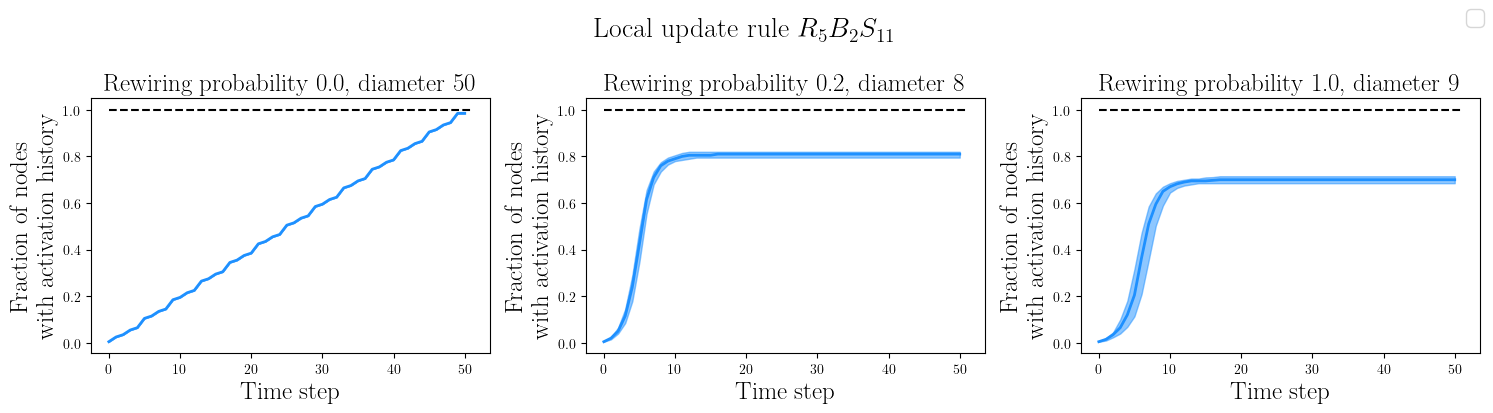

In [562]:
# make simple totalistic CA with radius 2
resolution = 5
beta = 2
sigma = 11
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
# model = LLNA(resolution, iso=True)
T = 50

# single-seed initial configuration for each node
init_configs = np.eye(num_nodes)

fig, axs = plt.subplots(1, prob_resolution, figsize=(5*prob_resolution, 4))
fontsize=18
alpha_factor = 0.03

for ws_edge, ws_graph, rewiring_prob, ax in tqdm(zip(ws_edges, ws_graphs, rewiring_probs, axs), total=prob_resolution):
    # run simulation over a number of time steps
    configs = model.forward(ws_edge, tc.tensor(init_configs), T=T).numpy().astype(int)
    # find nodes with an activation history with a 1
    configs_cum = np.cumsum(configs, axis=1)
    configs_cum = np.clip(configs_cum, 0, 1)
    # calculate the means over all nodes
    fraction_affected_nodes = np.mean(configs_cum, axis=2).T
    # calcule the quartiles for each time step
    Q1_of_fraction = np.quantile(fraction_affected_nodes, 0.25, axis=1)
    Q2_of_fraction = np.quantile(fraction_affected_nodes, 0.50, axis=1)
    Q3_of_fraction = np.quantile(fraction_affected_nodes, 0.75, axis=1)
    # plot
    ax.plot([0,T+1], [1,1], 'k--', zorder=10)
    ax.plot(Q2_of_fraction, lw=2, color=color, ls='-')
    ax.fill_between(range(T+1), Q1_of_fraction, Q3_of_fraction, lw=1, color=color, alpha=0.5)
    ax.set_title(f"Rewiring probability {round(rewiring_prob,2)}, diameter {ws_graph.diameter()}", fontsize=fontsize)
    ax.set_xlabel("Time step", fontsize=fontsize)
    ax.set_ylabel("Fraction of nodes\nwith activation history", fontsize=fontsize)
    # ax.set_ylim([-0.05, 1.05])

# axs[-1].legend(fontsize=fontsize-4, loc='lower right', ncol=3)

# Add a single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=len(init_dens_list), fontsize=fontsize-2, bbox_to_anchor=(1, 1.05) )

fig.suptitle(f"Local update rule {model.__str__(latex=True)}", fontsize=fontsize+2, y=1)
fig.tight_layout()

- R5 B3 S31 seems to be stuck
- R5 B10 S7 is quite interesting! Very different behaviour. Kind of similar to R5 B14 S28
- R5 B18 S4 looks like a complex rule!
- Most interesting so far: R5 B2 S11. Similar to R5 B2 S2. Interestingly, these are not very special in the other plots.

**Note**: using these two graphs, we can also estimate the 'density' of the affected nodes. In a spacetime diagram that would be the fraction of the living nodes from all the way left to all the way right in the defect cone.

# Behaviour over full rule space

Now we do not want to simply look at rule per rule, but at all the rules at the same time. We need to ...
- Create a metric that tells you something about the density for the final state of the system after starting with half of the nodes alive
- Create a metric that tells you something about the eventual fraction of activated nodes after seeding the system
- Run over all non-equivalent LLNAs of a particular resolution
- Plot the metrics against each other

Note that this is _purely empirical_, and _purely looking at states_. Later we will
- Compare with damage spreading
- Compare with theoretical concepts to figure out which metrics can tell you something about the system.

One interesting one is to compare the value that the system "should" converge to (if it would operate in the mean-field way), versus the value that it actually converged to, given a particular initial configuration. And then this difference can be used as some kind of metric for how unpredictable the system is.

But first: the project above. Let's start simple, by just only looking at the means. This does not account for the large variance found in these systems, but this can be added later.

In [563]:
def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

In [604]:
# setup
T = 50
t_window = 10
init_dens = 0.5
num_config = 50

# pick network
ws_graph = ws_graphs[0]
ws_edge = ws_edges[0]

# pick rule params
resolution = 5
betas = range(2**resolution)
sigmas = range(2**resolution)

# iterate over non-equivalent rules
equiv_rules = []
nonequiv_rules = []
final_configs_mean_list = []
fraction_affected_nodes_list = []
for beta in tqdm(betas, total=2**resolution):
    for sigma in sigmas:
        # equivalence bookkeeping
        if (beta, sigma) in equiv_rules:
            continue
        B_set = binary_indices(beta)
        S_set = binary_indices(sigma)
        beta_equiv, sigma_equiv = return_equivalent_rule(resolution, B_set, S_set, return_decimals=True)
        if not ((beta == beta_equiv) and (sigma == sigma_equiv)):
            equiv_rules.append((beta_equiv, sigma_equiv))
        nonequiv_rules.append((beta, sigma))
        # create model
        model = LLNA(resolution, B_set, S_set, iso=True)

        # initial configuration with density 0.5
        init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
        # run simulation over a number of time steps
        configs = model.forward(ws_edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        # only take the final `t_window` steps
        final_configs = configs[:,-t_window:]
        # literally just take the mean of all nodes and of all samples, over the last `t_window` steps. Quite naive, I guess
        final_configs_mean = np.mean(final_configs)
        final_configs_mean_list.append(final_configs_mean)

        # initial configuration with single seed
        init_configs = np.eye(num_nodes, dtype=int)
        # run num_nodes simulation over T time steps  
        configs = model.forward(ws_edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        # find nodes with an activation history with a 1
        configs_cum = np.cumsum(configs, axis=1)
        configs_cum = np.clip(configs_cum, 0, 1)
        # calculate the means over all nodes and all samples in the final time step
        fraction_affected_nodes = np.mean(configs_cum[:,-1,:]).T
        fraction_affected_nodes_list.append(fraction_affected_nodes)

100%|██████████| 32/32 [03:39<00:00,  6.87s/it]


Text(0, 0.5, 'Fraction of nodes that will get affected after seeding')

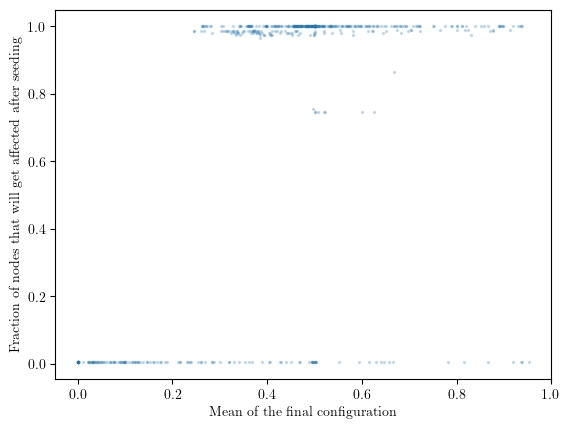

In [ ]:
# this does not really say all that much. That's because the fraction of affected nodes is very bipolar. I suspect this is different for other networks!
plt.scatter(final_configs_mean_list, fraction_affected_nodes_list, s=10, alpha=0.2)
plt.xlabel("Mean of the final configuration")
plt.ylabel("Fraction of nodes that will get affected after seeding")
plt.title("Regular network")

Let's do the same but for a fully random network. That's bound to be different!

In [609]:
# setup
T = 50
t_window = 10
init_dens = 0.5
num_config = 50

# pick network
ws_graph = ws_graphs[2]
ws_edge = ws_edges[2]

# pick rule params
resolution = 5
betas = range(2**resolution)
sigmas = range(2**resolution)

# iterate over non-equivalent rules
equiv_rules = []
nonequiv_rules = []
final_configs_mean_list = []
fraction_affected_nodes_list = []
for beta in tqdm(betas, total=2**resolution):
    for sigma in sigmas:
        # equivalence bookkeeping
        if (beta, sigma) in equiv_rules:
            continue
        B_set = binary_indices(beta)
        S_set = binary_indices(sigma)
        beta_equiv, sigma_equiv = return_equivalent_rule(resolution, B_set, S_set, return_decimals=True)
        if not ((beta == beta_equiv) and (sigma == sigma_equiv)):
            equiv_rules.append((beta_equiv, sigma_equiv))
        nonequiv_rules.append((beta, sigma))
        # create model
        model = LLNA(resolution, B_set, S_set, iso=True)

        # initial configuration with density 0.5
        init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
        # run simulation over a number of time steps
        configs = model.forward(ws_edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        # only take the final `t_window` steps
        final_configs = configs[:,-t_window:]
        # literally just take the mean of all nodes and of all samples, over the last `t_window` steps. Quite naive, I guess
        final_configs_mean = np.mean(final_configs)
        final_configs_mean_list.append(final_configs_mean)

        # initial configuration with single seed
        init_configs = np.eye(num_nodes, dtype=int)
        # run num_nodes simulation over T time steps  
        configs = model.forward(ws_edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        # find nodes with an activation history with a 1
        configs_cum = np.cumsum(configs, axis=1)
        configs_cum = np.clip(configs_cum, 0, 1)
        # calculate the means over all nodes and all samples in the final time step
        fraction_affected_nodes = np.mean(configs_cum[:,-1,:]).T
        fraction_affected_nodes_list.append(fraction_affected_nodes)

100%|██████████| 32/32 [04:11<00:00,  7.87s/it]


Text(0.5, 1.0, 'Random network')

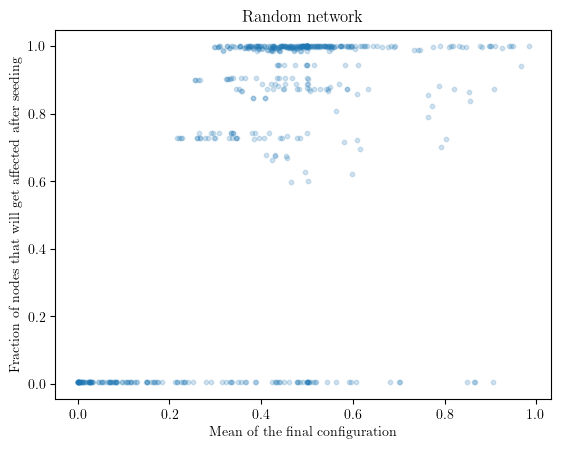

In [610]:
# this does not really say all that much. That's because the fraction of affected nodes is very bipolar. I suspect this is different for other networks!
plt.scatter(final_configs_mean_list, fraction_affected_nodes_list, s=10, alpha=0.2)
plt.xlabel("Mean of the final configuration")
plt.ylabel("Fraction of nodes that will get affected after seeding")
plt.title("Random network")

This is a bit more spread out, but still not all that much. Perhaps there is another metric that is more useful to investigate?